In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [140]:
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 2)

In [94]:
df = pd.read_csv(
    "/home/arthur/workspace/analytics/data/data.csv", encoding="windows-1251", sep=","
)

In [117]:
targets = [
    "out_acceptionsDurations",
    "inner_same_bu_acceptionsDurations",
    "inner_diff_bu_acceptionsDurations",
]

In [95]:
selected_columns = [
    "warehouse_number",
    "warehouse_cd",
    "date",
    "out_acceptionsDurations",
    "inner_same_bu_acceptionsDurations",
    "inner_diff_bu_acceptionsDurations",
]

In [96]:
df = df.loc[:, selected_columns]

In [10]:
df.head()

,warehouse_number,warehouse_cd,date,out_acceptionsDurations,inner_same_bu_acceptionsDurations,inner_diff_bu_acceptionsDurations
0,1021,1021_0005,2025-12-31,0,2232,0
1,1021,1021_0003,2025-12-31,0,692,0
2,1021,1021_0072,2025-12-30,14291,0,109
3,1021,1021_0015,2025-12-30,0,0,72
4,1021,1021_0011,2025-12-30,760,15,0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1716 entries, 0 to 1715
Data columns (total 6 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   warehouse_number                   1716 non-null   int64
 1   warehouse_cd                       1716 non-null   str  
 2   date                               1716 non-null   str  
 3   out_acceptionsDurations            1716 non-null   int64
 4   inner_same_bu_acceptionsDurations  1716 non-null   int64
 5   inner_diff_bu_acceptionsDurations  1716 non-null   int64
dtypes: int64(4), str(2)
memory usage: 80.6 KB


In [97]:
df["date"] = pd.to_datetime(df["date"])
df["warehouse_number"] = df["warehouse_number"].astype("str")

In [98]:
df.describe(exclude="str")

,date,out_acceptionsDurations,inner_same_bu_acceptionsDurations,inner_diff_bu_acceptionsDurations
count,1716,1716.000000,1716.000000,1716.000000
mean,2025-09-17 16:20:58.741258,14428.972028,3211.457459,38.376457
min,2025-06-01 00:00:00,0.000000,0.000000,0.000000
25%,2025-07-26 00:00:00,545.000000,0.000000,0.000000
50%,2025-09-19 00:00:00,4024.000000,72.000000,0.000000
75%,2025-11-11 00:00:00,18000.000000,1054.500000,0.000000
max,2025-12-31 00:00:00,158688.000000,142560.000000,13392.000000
std,NaN,22699.213303,11135.250160,440.545080


In [99]:
df["warehouse_cd"].unique()

<StringArray>
['1021_0005', '1021_0003', '1021_0072', '1021_0015', '1021_0011', '1021_0009',
 '1021_0007', '1021_0004', '1021_0002']
Length: 9, dtype: str

In [100]:
df.groupby(["warehouse_cd"]).agg({"out_acceptionsDurations": ["count", "mean"]}).assign(
    max=lambda x: max(x[("out_acceptionsDurations", "count")])
)

out_acceptionsDurations                max
                               count          mean     
warehouse_cd                                           
1021_0002                        208   3212.725962  214
1021_0003                        211  23032.473934  214
1021_0004                        211  11254.127962  214
1021_0005                        214  63434.355140  214
1021_0007                        211  11063.507109  214
1021_0009                         72    966.069444  214
1021_0011                        175    247.171429  214
1021_0015                        207    618.434783  214
1021_0072                        207   3416.502415  214

In [101]:
full_calendar = pd.DataFrame(pd.date_range(df["date"].min(), df["date"].max()))

In [102]:
full_calendar.values.reshape(-1, 1)

array([['2025-06-01T00:00:00.000000'],
       ['2025-06-02T00:00:00.000000'],
       ['2025-06-03T00:00:00.000000'],
       ['2025-06-04T00:00:00.000000'],
       ['2025-06-05T00:00:00.000000'],
       ['2025-06-06T00:00:00.000000'],
       ['2025-06-07T00:00:00.000000'],
       ['2025-06-08T00:00:00.000000'],
       ['2025-06-09T00:00:00.000000'],
       ['2025-06-10T00:00:00.000000'],
       ['2025-06-11T00:00:00.000000'],
       ['2025-06-12T00:00:00.000000'],
       ['2025-06-13T00:00:00.000000'],
       ['2025-06-14T00:00:00.000000'],
       ['2025-06-15T00:00:00.000000'],
       ['2025-06-16T00:00:00.000000'],
       ['2025-06-17T00:00:00.000000'],
       ['2025-06-18T00:00:00.000000'],
       ['2025-06-19T00:00:00.000000'],
       ['2025-06-20T00:00:00.000000'],
       ['2025-06-21T00:00:00.000000'],
       ['2025-06-22T00:00:00.000000'],
       ['2025-06-23T00:00:00.000000'],
       ['2025-06-24T00:00:00.000000'],
       ['2025-06-25T00:00:00.000000'],
       ['2025-06-26T00:00

In [103]:
from itertools import product

In [104]:
[x[0] for x in full_calendar.values.tolist()]

[datetime.datetime(2025, 6, 1, 0, 0),
 datetime.datetime(2025, 6, 2, 0, 0),
 datetime.datetime(2025, 6, 3, 0, 0),
 datetime.datetime(2025, 6, 4, 0, 0),
 datetime.datetime(2025, 6, 5, 0, 0),
 datetime.datetime(2025, 6, 6, 0, 0),
 datetime.datetime(2025, 6, 7, 0, 0),
 datetime.datetime(2025, 6, 8, 0, 0),
 datetime.datetime(2025, 6, 9, 0, 0),
 datetime.datetime(2025, 6, 10, 0, 0),
 datetime.datetime(2025, 6, 11, 0, 0),
 datetime.datetime(2025, 6, 12, 0, 0),
 datetime.datetime(2025, 6, 13, 0, 0),
 datetime.datetime(2025, 6, 14, 0, 0),
 datetime.datetime(2025, 6, 15, 0, 0),
 datetime.datetime(2025, 6, 16, 0, 0),
 datetime.datetime(2025, 6, 17, 0, 0),
 datetime.datetime(2025, 6, 18, 0, 0),
 datetime.datetime(2025, 6, 19, 0, 0),
 datetime.datetime(2025, 6, 20, 0, 0),
 datetime.datetime(2025, 6, 21, 0, 0),
 datetime.datetime(2025, 6, 22, 0, 0),
 datetime.datetime(2025, 6, 23, 0, 0),
 datetime.datetime(2025, 6, 24, 0, 0),
 datetime.datetime(2025, 6, 25, 0, 0),
 datetime.datetime(2025, 6, 26, 0,

In [105]:
list(
    product(df["warehouse_cd"].unique(), [x[0] for x in full_calendar.values.tolist()])
)

[('1021_0005', datetime.datetime(2025, 6, 1, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 2, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 3, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 4, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 5, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 6, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 7, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 8, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 9, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 10, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 11, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 12, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 13, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 14, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 15, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 16, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 17, 0, 0)),
 ('1021_0005', datetime.datetime(2025, 6, 18, 0, 0)),
 ('1021_0005', datetime.datetime(2025

In [106]:
typles = list(
    product(df["warehouse_cd"].unique(), [x[0] for x in full_calendar.values.tolist()])
)

In [107]:
idx = pd.MultiIndex.from_tuples(typles, names=["wh", "dt"])

In [108]:
full_index = pd.DataFrame(index=idx).index

In [110]:
df = df.set_index(["warehouse_cd", "date"])

In [111]:
df = df.reindex(full_index)

In [122]:
df[targets].isna().sum()

out_acceptionsDurations              0
inner_same_bu_acceptionsDurations    0
inner_diff_bu_acceptionsDurations    0
dtype: int64

In [121]:
df.loc[:, targets] = df.loc[:, targets].fillna(0)

In [131]:
# Найдем все нули для targets
df.reset_index().groupby("wh").apply(lambda x: (x == 0).sum())

,dt,warehouse_number,out_acceptionsDurations,inner_same_bu_acceptionsDurations,inner_diff_bu_acceptionsDurations
wh,,,,,
1021_0002,0,0,14,120,175
1021_0003,0,0,9,64,208
1021_0004,0,0,17,98,198
1021_0005,0,0,1,17,157
1021_0007,0,0,8,115,185
1021_0009,0,0,145,188,198
1021_0011,0,0,64,108,212
1021_0015,0,0,19,150,210
1021_0072,0,0,12,97,206


In [133]:
# Проверим распределение


def q95(x: pd.Series):
    return x.quantile(0.95)


def q99(x: pd.Series):
    return x.quantile(0.99)

In [142]:
df.groupby("wh")[targets].agg(["mean", "median", "max", q95, q99, "std"]) / 60

out_acceptionsDurations                                              \
                             mean   median      max      q95      q99     std   
wh                                                                              
1021_0002                   52.04    45.00   188.83   144.80   171.80   45.35   
1021_0003                  378.49   356.54  1098.45   756.93   916.57  219.87   
1021_0004                  184.94   156.92   572.32   446.54   548.63  142.05   
1021_0005                 1057.24  1087.20  2644.80  1675.74  2099.75  425.70   
1021_0007                  181.81   146.67   606.67   469.00   529.13  150.71   
1021_0009                    5.42     0.00    90.60    30.57    63.90   13.43   
1021_0011                    3.37     1.02   149.22    12.15    37.69   11.86   
1021_0015                    9.97     7.20    80.40    28.80    36.73   10.06   
1021_0072                   55.08    37.27   314.53   163.09   235.88   54.50   

          inner_same_bu_acceptionsDurations                            \
                                       mean  median      max      q95   
wh                                                                      
1021_0002                              5.96    0.00   120.00    28.23   
1021_0003                             17.66    6.92   336.92    63.92   
1021_0004                             27.20    4.62   323.07   112.38   
1021_0005                            349.23  226.20  2376.00  1216.56   
1021_0007                             16.78    0.00   253.33    92.33   
1021_0009                              1.17    0.00    37.27     7.47   
1021_0011                              1.01    0.00    77.25     2.34   
1021_0015                              1.03    0.00    28.80     4.02   
1021_0072                              9.15    1.82   141.82    38.82   

                           inner_diff_bu_acceptionsDurations                 \
               q99     std                              mean median     max   
wh                                                                            
1021_0002    43.89   12.72                              0.54    0.0    7.07   
1021_0003   107.87   32.19                              0.09    0.0    6.92   
1021_0004   204.70   47.21                              1.10    0.0   96.92   
1021_0005  1881.44  413.93                              2.47    0.0  223.20   
1021_0007   155.37   35.17                              0.62    0.0   13.33   
1021_0009    31.41    4.91                              0.10    0.0    5.55   
1021_0011    16.84    5.67                              0.01    0.0    1.85   
1021_0015    11.84    2.88                              0.03    0.0    2.40   
1021_0072    94.16   18.27                              0.16    0.0   21.82   

                              
            q95   q99    std  
wh                            
1021_0002  3.53  7.07   1.39  
1021_0003  0.00  2.30   0.58  
1021_0004  4.62  9.23   7.74  
1021_0005  4.80  9.60  19.01  
1021_0007  3.33  6.67   1.81  
1021_0009  0.64  2.32   0.51  
1021_0011  0.00  0.00   0.13  
1021_0015  0.00  1.20   0.22  
1021_0072  0.00  1.82   1.52

Смотрим временные ряды

In [145]:
# params
wh = "1021_0005"
target = "out_acceptionsDurations"

In [182]:
tmp = df.reset_index(0)
tmp = tmp.loc[tmp["wh"] == wh, target].reset_index()
tmp = tmp.set_index("dt")

In [193]:
tmp.assign(rolling=lambda x: x[target].rolling(7).mean())["rolling"]

dt
2025-06-01         NaN
2025-06-02         NaN
2025-06-03         NaN
2025-06-04         NaN
2025-06-05         NaN
                ...   
2025-12-27    72257.14
2025-12-28    68914.29
2025-12-29    70508.57
2025-12-30    65077.71
2025-12-31    55522.29
Name: rolling, Length: 214, dtype: float64

In [206]:
tmp = tmp.reset_index()

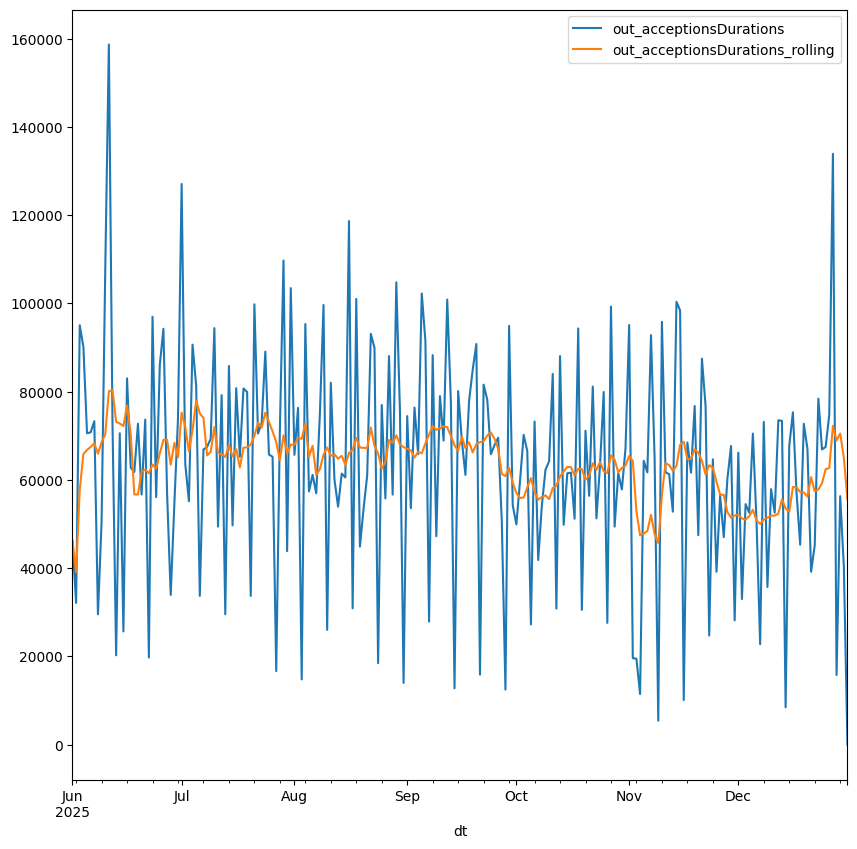

In [210]:
fig, ax = plt.subplots(figsize=(10, 10))

tmp.plot(x="dt", y="out_acceptionsDurations", ax=ax)
tmp.plot(x="dt", y="out_acceptionsDurations_rolling", ax=ax)
# tmp.plot(tmp.index, tmp['out_acceptionsDurations_rolling'],ax=ax)
plt.show()

In [198]:
tmp[f"{target}_rolling"] = tmp[target].rolling(7, min_periods=1).mean()

In [202]:
tmp

,out_acceptionsDurations,out_acceptionsDurations_rolling
dt,,
2025-06-01,46080.0,46080.00
2025-06-02,32112.0,39096.00
2025-06-03,95040.0,57744.00
2025-06-04,90144.0,65844.00
2025-06-05,70560.0,66787.20
...,...,...
2025-12-27,133920.0,72257.14
2025-12-28,15768.0,68914.29
2025-12-29,56304.0,70508.57


In [144]:
df.head(3)

warehouse_number  out_acceptionsDurations  \
wh        dt                                                     
1021_0005 2025-06-01             1021                  46080.0   
          2025-06-02             1021                  32112.0   
          2025-06-03             1021                  95040.0   

                      inner_same_bu_acceptionsDurations  \
wh        dt                                              
1021_0005 2025-06-01                            10296.0   
          2025-06-02                            77688.0   
          2025-06-03                            12528.0   

                      inner_diff_bu_acceptionsDurations  
wh        dt                                             
1021_0005 2025-06-01                                0.0  
          2025-06-02                                0.0  
          2025-06-03                                0.0